
Predicted probabilities (first 20 patients) with true diagnosis:
    Patient  True Diagnosis  Logistic Regression (%)  Random Forest (%)  \
0         1               1                    79.35              78.96   
1         2               0                     0.30               1.16   
2         3               0                     0.30               4.07   
3         4               0                     5.63              13.09   
4         5               0                     0.00               0.18   
5         6               0                    58.82              65.57   
6         7               0                    21.99              28.99   
7         8               0                    17.32              18.73   
8         9               0                     1.68               2.32   
9        10               0                    17.63              19.26   
10       11               0                     1.02               3.14   
11       12               0       

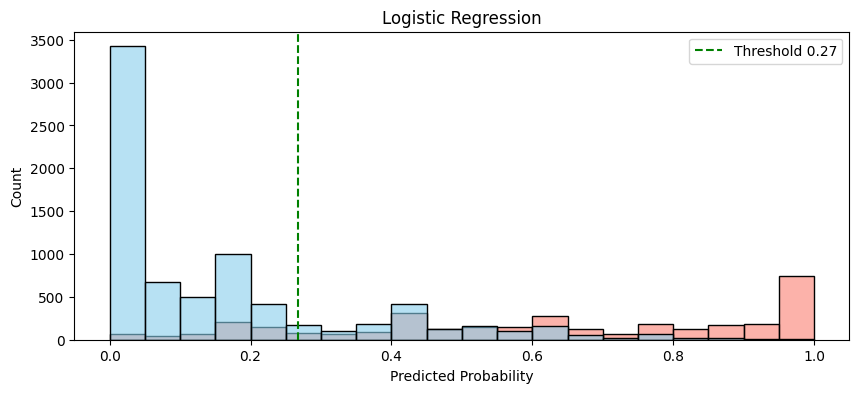

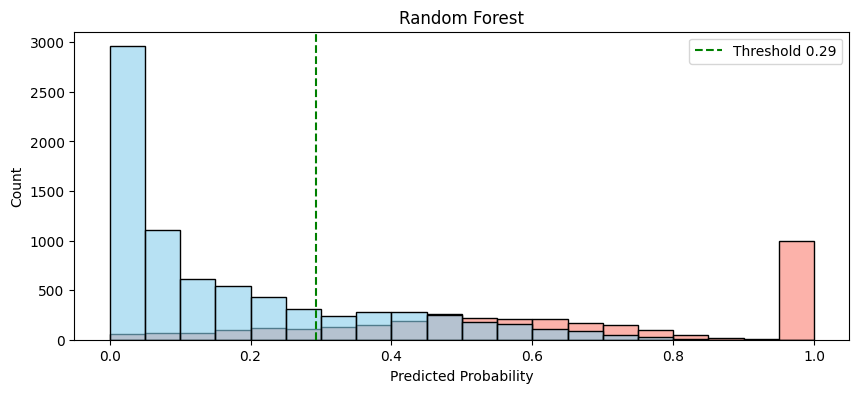

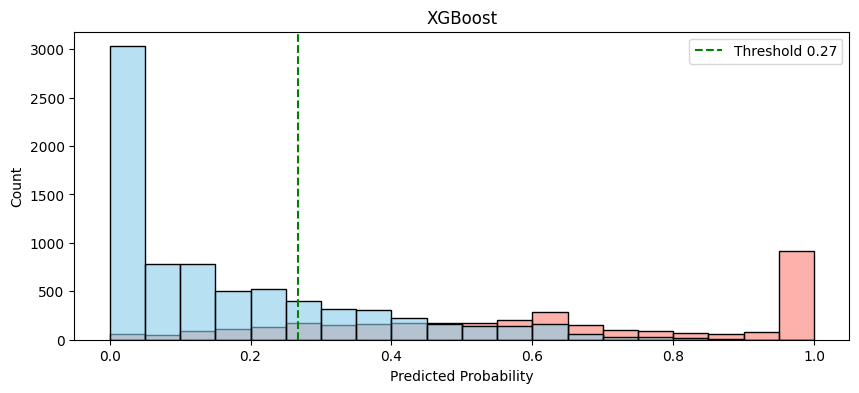


Logistic Regression METRICS (threshold=0.267)
Confusion Matrix:
  True Negatives: 6044
  False Positives: 1574
  False Negatives: 547
  True Positives: 2835

Key Performance Metrics:
  • SENSITIVITY (Recall/True Positive Rate): 0.8383 (83.83%)
  • SPECIFICITY (True Negative Rate): 0.7934 (79.34%)
  • F1-SCORE: 0.7278

Additional Metrics:
  Accuracy: 0.8072 (80.72%)
  Precision: 0.6430 (64.30%)
  ROC AUC: 0.9047
  Brier Score: 0.1114

Classification Report:
              precision    recall  f1-score   support

           0     0.9170    0.7934    0.8507      7618
           1     0.6430    0.8383    0.7278      3382

    accuracy                         0.8072     11000
   macro avg     0.7800    0.8158    0.7892     11000
weighted avg     0.8328    0.8072    0.8129     11000


Random Forest METRICS (threshold=0.293)
Confusion Matrix:
  True Negatives: 5923
  False Positives: 1695
  False Negatives: 510
  True Positives: 2872

Key Performance Metrics:
  • SENSITIVITY (Recall/True Posi

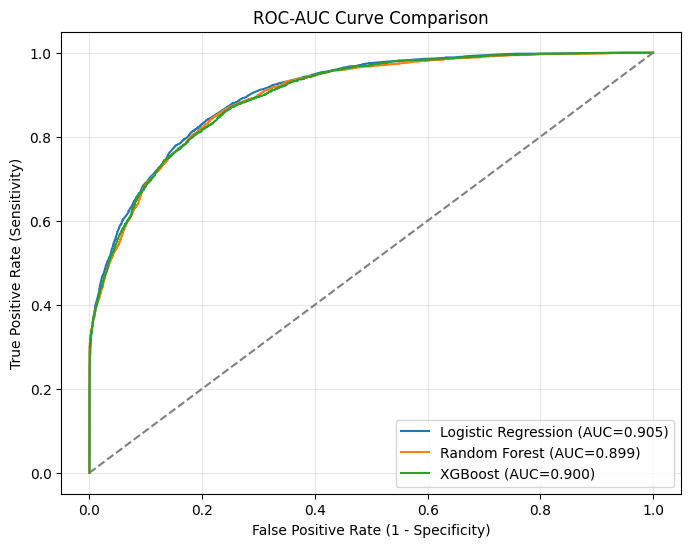

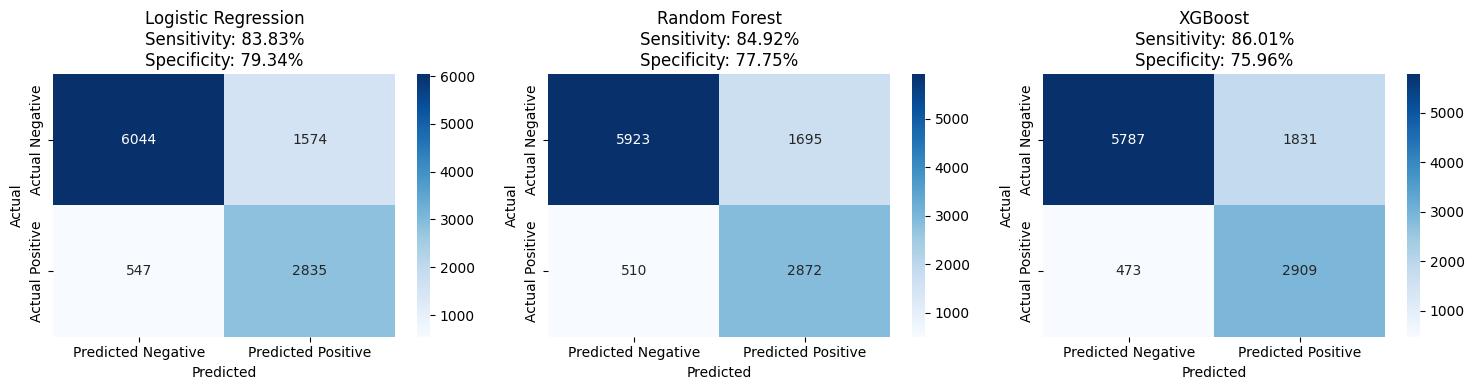

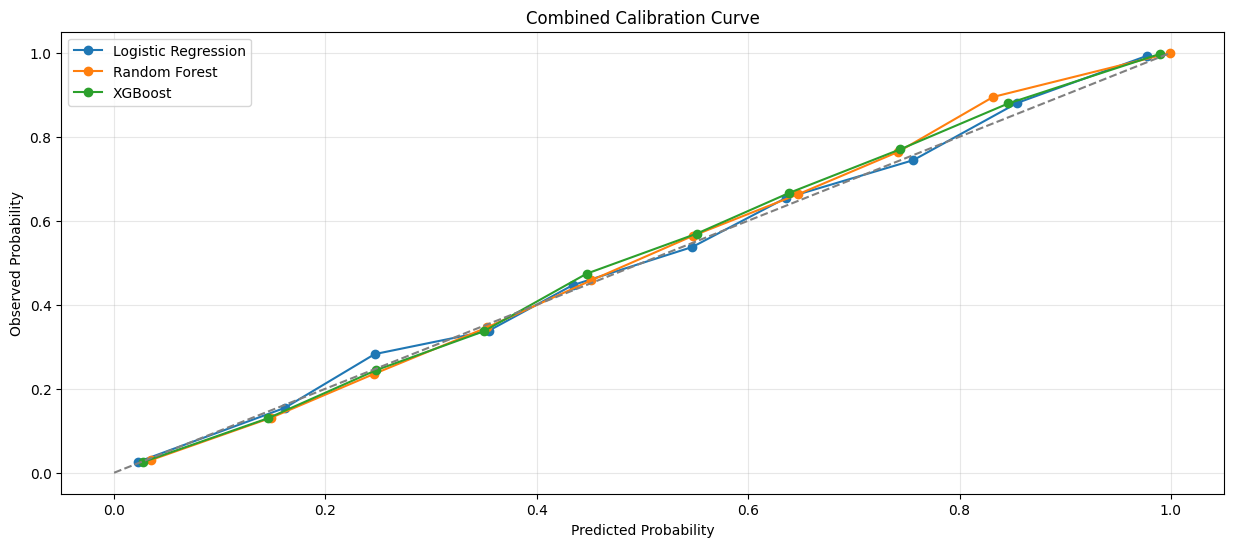


Model saved as predictive_model.pkl


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.utils import shuffle
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    roc_auc_score, accuracy_score, roc_curve, brier_score_loss,
    precision_score, recall_score, f1_score, confusion_matrix, classification_report
)

# Load and prepare training data
train_data = pd.read_csv("training_dataset.csv")
X_train = train_data.drop(columns=["Diagnosed", "Anxiety Level (1-10)"])
y_train = train_data["Diagnosed"]
X_train, y_train = shuffle(X_train, y_train, random_state=42)

# Load and prepare test data
test_data = pd.read_csv("testing_dataset.csv")
X_test = test_data.drop(columns=["Diagnosed", "Anxiety Level (1-10)"])
y_test = test_data["Diagnosed"]

# Identify feature types
numeric_features = X_train.select_dtypes(include=[float, int]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

# Create preprocessing pipeline
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical_features)
])

# Create model pipelines
logreg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", solver="saga", l1_ratio=0.5, C=1.0))
])

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42))
])

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                                 eval_metric="logloss", scale_pos_weight=scale_pos_weight, random_state=42))
])

# Calibrate models
logreg_model = CalibratedClassifierCV(logreg_pipeline, method="isotonic", cv=5)
rf_model = CalibratedClassifierCV(rf_pipeline, method="isotonic", cv=5)
xgb_model = CalibratedClassifierCV(xgb_pipeline, method="isotonic", cv=5)

# Train models
logreg_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)


# Get predicted probabilities
logreg_prob = logreg_model.predict_proba(X_test)[:, 1]
rf_prob = rf_model.predict_proba(X_test)[:, 1]
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

# Show first 20 predictions
print("\nPredicted probabilities (first 20 patients) with true diagnosis:")
df_probs = pd.DataFrame({
    "Patient": range(1, 21),
    "True Diagnosis": y_test.iloc[:20].values,
    "Logistic Regression (%)": np.round(logreg_prob[:20]*100, 2),
    "Random Forest (%)": np.round(rf_prob[:20]*100, 2),
    "XGBoost (%)": np.round(xgb_prob[:20]*100, 2)
})
print(df_probs)

# Find optimal thresholds
def find_best_threshold(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    best_idx = np.argmax(tpr - fpr)
    return thresholds[best_idx]

logreg_threshold = find_best_threshold(y_test, logreg_prob)
rf_threshold = find_best_threshold(y_test, rf_prob)
xgb_threshold = find_best_threshold(y_test, xgb_prob)

# Plot probability distributions
def plot_probabilities_horizontal(y_true, y_prob, threshold, name):
    df = pd.DataFrame({"Probability": y_prob, "Diagnosis": y_true})
    plt.figure(figsize=(10, 4))
    sns.histplot(data=df, x="Probability", hue="Diagnosis", bins=20, palette=["skyblue", "salmon"], alpha=0.6)
    plt.axvline(threshold, color="green", linestyle="--", label=f"Threshold {threshold:.2f}")
    plt.xlabel("Predicted Probability")
    plt.ylabel("Count")
    plt.title(name)
    plt.legend()
    plt.show()

plot_probabilities_horizontal(y_test, logreg_prob, logreg_threshold, "Logistic Regression")
plot_probabilities_horizontal(y_test, rf_prob, rf_threshold, "Random Forest")
plot_probabilities_horizontal(y_test, xgb_prob, xgb_threshold, "XGBoost")

# Plot feature importance
def plot_feature_importance(pipeline_model, name):
    classifier = pipeline_model.named_steps["classifier"]
    if hasattr(classifier, "feature_importances_"):
        importances = classifier.feature_importances_
        feature_names_tree = list(preprocessor.transformers_[0][2]) + list(preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features))
        indices = np.argsort(importances)[-15:]
        plt.figure(figsize=(8, 5))
        plt.barh(range(len(indices)), importances[indices])
        plt.yticks(range(len(indices)), [feature_names_tree[i] for i in indices])
        plt.title(name + " Feature Importance")
        plt.show()

plot_feature_importance(rf_pipeline, "Random Forest")
plot_feature_importance(xgb_pipeline, "XGBoost")

# MODIFIED: Enhanced evaluate_model function with explicit sensitivity, specificity, and F1-score
def evaluate_model(y_true, y_prob, threshold, name):
    y_pred = (y_prob >= threshold).astype(int)
    
    # Calculate confusion matrix components
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    # Calculate metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)  # This is sensitivity
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)
    brier = brier_score_loss(y_true, y_prob)
    
    # Calculate sensitivity and specificity explicitly
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # Same as recall
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    print(f"\n{'='*50}")
    print(f"{name} METRICS (threshold={threshold:.3f})")
    print(f"{'='*50}")
    print(f"Confusion Matrix:")
    print(f"  True Negatives: {tn}")
    print(f"  False Positives: {fp}")
    print(f"  False Negatives: {fn}")
    print(f"  True Positives: {tp}")
    print(f"\nKey Performance Metrics:")
    print(f"  • SENSITIVITY (Recall/True Positive Rate): {sensitivity:.4f} ({sensitivity*100:.2f}%)")
    print(f"  • SPECIFICITY (True Negative Rate): {specificity:.4f} ({specificity*100:.2f}%)")
    print(f"  • F1-SCORE: {f1:.4f}")
    print(f"\nAdditional Metrics:")
    print(f"  Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print(f"  Precision: {prec:.4f} ({prec*100:.2f}%)")
    print(f"  ROC AUC: {roc_auc:.4f}")
    print(f"  Brier Score: {brier:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4))
    
    return confusion_matrix(y_true, y_pred), {
        'sensitivity': sensitivity,
        'specificity': specificity,
        'f1_score': f1,
        'precision': prec,
        'accuracy': acc,
        'roc_auc': roc_auc
    }

# Evaluate models and store metrics
logreg_cm, logreg_metrics = evaluate_model(y_test, logreg_prob, logreg_threshold, "Logistic Regression")
rf_cm, rf_metrics = evaluate_model(y_test, rf_prob, rf_threshold, "Random Forest")
xgb_cm, xgb_metrics = evaluate_model(y_test, xgb_prob, xgb_threshold, "XGBoost")

# NEW: Create a comparison table of the key metrics
print(f"\n{'='*60}")
print("MODEL COMPARISON SUMMARY")
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Threshold': [logreg_threshold, rf_threshold, xgb_threshold],
    'Sensitivity (%)': [logreg_metrics['sensitivity']*100, rf_metrics['sensitivity']*100, xgb_metrics['sensitivity']*100],
    'Specificity (%)': [logreg_metrics['specificity']*100, rf_metrics['specificity']*100, xgb_metrics['specificity']*100],
    'F1-Score': [logreg_metrics['f1_score'], rf_metrics['f1_score'], xgb_metrics['f1_score']],
    'Precision (%)': [logreg_metrics['precision']*100, rf_metrics['precision']*100, xgb_metrics['precision']*100],
    'Accuracy (%)': [logreg_metrics['accuracy']*100, rf_metrics['accuracy']*100, xgb_metrics['accuracy']*100],
    'ROC-AUC': [logreg_metrics['roc_auc'], rf_metrics['roc_auc'], xgb_metrics['roc_auc']]
})

# Format the dataframe for better display
comparison_df = comparison_df.round(2)
print("\n", comparison_df.to_string(index=False))

# NEW: Identify the best model for different clinical scenarios
print(f"\n{'='*60}")
print("CLINICAL RECOMMENDATIONS BASED ON METRICS")
print(f"{'='*60}")

# Find best for different scenarios
best_sensitivity_model = comparison_df.loc[comparison_df['Sensitivity (%)'].idxmax(), 'Model']
best_specificity_model = comparison_df.loc[comparison_df['Specificity (%)'].idxmax(), 'Model']
best_f1_model = comparison_df.loc[comparison_df['F1-Score'].idxmax(), 'Model']
best_balance_model = comparison_df.loc[(comparison_df['Sensitivity (%)'] + comparison_df['Specificity (%)']).idxmax(), 'Model']

print(f"\n• For SCREENING (prioritize catching all cases - HIGH SENSITIVITY):")
print(f"  → Best model: {best_sensitivity_model} ({comparison_df.loc[comparison_df['Model']==best_sensitivity_model, 'Sensitivity (%)'].values[0]:.1f}% sensitivity)")

print(f"\n• For CONFIRMATORY testing (prioritize avoiding false alarms - HIGH SPECIFICITY):")
print(f"  → Best model: {best_specificity_model} ({comparison_df.loc[comparison_df['Model']==best_specificity_model, 'Specificity (%)'].values[0]:.1f}% specificity)")

print(f"\n• For OVERALL BALANCE (highest F1-score + sensitivity+specificity):")
print(f"  → Best model: {best_balance_model} (F1={comparison_df.loc[comparison_df['Model']==best_balance_model, 'F1-Score'].values[0]:.2f})")

# Plot ROC curves
plt.figure(figsize=(8,6))
for prob, label in zip([logreg_prob, rf_prob, xgb_prob], ["Logistic Regression", "Random Forest", "XGBoost"]):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{label} (AUC={auc:.3f})")
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC-AUC Curve Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Plot confusion matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Add annotations with sensitivity and specificity for each
sensitivity_labels = [
    f"Sensitivity: {logreg_metrics['sensitivity']:.2%}\nSpecificity: {logreg_metrics['specificity']:.2%}",
    f"Sensitivity: {rf_metrics['sensitivity']:.2%}\nSpecificity: {rf_metrics['specificity']:.2%}",
    f"Sensitivity: {xgb_metrics['sensitivity']:.2%}\nSpecificity: {xgb_metrics['specificity']:.2%}"
]

for idx, (cm, ax, label) in enumerate(zip([logreg_cm, rf_cm, xgb_cm], axes, sensitivity_labels)):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, 
                xticklabels=['Predicted Negative', 'Predicted Positive'],
                yticklabels=['Actual Negative', 'Actual Positive'])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"{['Logistic Regression', 'Random Forest', 'XGBoost'][idx]}\n{label}")

plt.tight_layout()
plt.show()

# Plot calibration curves
plt.figure(figsize=(15,6))
for prob, label in zip([logreg_prob, rf_prob, xgb_prob], ["Logistic Regression", "Random Forest", "XGBoost"]):
    prob_true, prob_pred = calibration_curve(y_test, prob, n_bins=10)
    plt.plot(prob_pred, prob_true, marker='o', label=label)
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Probability")
plt.title("Combined Calibration Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Save model
joblib.dump(xgb_model, 'predictive_model.pkl', compress=3)
print("\nModel saved as predictive_model.pkl")